# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Faryal Gul

**Roll Number:**

**GitHub Repository:**

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Load the dataset
#df = pd.read_csv("telco_churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

t**Answer 1:**
The bussiness problem is that a telecommunication company is losing customers to competitors and now the company wants to know which customers are likely to leave the company. The target variable is churn which represents whether a customer leaves the company or stays.

**Answer 2:**
contract, tenure, senior citizen, monthly charges, online security

**Answer 3:**
customerID, partner

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [4]:
# Task 4 — dataset shape, column names, data types
df.shape
df.columns
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [13]:
# Task 5 — identify identifier columns / wrong data types
df.columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Task 6 — unique values in 3 categorical columns
print(df["gender"].unique())
print(df["InternetService"].unique())
print(df["PaymentMethod"].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

numerical features: SeniorCitizen, tenure, MonthlyCharges

categorical features: gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, TotalCharges, Churn

suspicious columns: TotalCharges is suspicious column because it should numerical but it is categorical.

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [6]:
# Task 7 — missing values: count and percentage per column
missing=pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage" :df.isnull().mean()*100
}
)
print(missing)


                  missing_count  missing_percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [7]:
# Task 8 — duplicate rows vs duplicate IDs

print("duplicate_count : ",df.duplicated().sum())
print("duplicate_id_count : ",df["customerID"].duplicated().sum())



duplicate_count :  0
duplicate_id_count :  0


In [8]:
# Task 9 — investigate a suspicious / invalid value
df["TotalCharges"].dtypes
df["TotalCharges"].value_counts()
df["TotalCharges"].unique()


<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

**Answer 7 (which missing-value problems need action, and why):**
There are no missing values in any column. All columns have 0 missing values and missing percentage of 0% so no missing treatment is required for this dataset.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
duplicate row and duplicate IDs both are different issues because duplicate row means the entire record is repeated whereas duplicate IDs mean the same customer identifier appears in multiple rows.

**Answer 9 (suspicious value found and how):**
The TotalCharges column is suspicious because it represents the total amount charged to a customer which means it should be numerical but its values are stored as strings. I identified it by checking the columns values and data types.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision                             | Method Used                      | Reason                                                                                                                                                                                               |
|---|--------------------------------------|----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| _e.g. TotalCharges stored as text_ | it should be converted to munerical  | pd.to_numeric(s,errors='coerce') | This method converts numeric values stored as text into a numerical data type and if it fails to convert any value to number it replaces it with nan which can then be handled using dropna or filna |
| _..._ | _..._                                | _..._                            | _..._                                                                                                                                                                                                |
| _..._ | _..._                                | _..._                            | _..._                                                                                                                                                                                                |

In [9]:
# Task 11 — apply your cleaning decisions here
df_clean=df.copy() # making a copy of original dataframe and cleaning it
df_clean["TotalCharges"]=pd.to_numeric(df_clean["TotalCharges"],errors="coerce")
print(df_clean["TotalCharges"].dtypes)
df_clean=df_clean.dropna()
df_clean=df_clean.drop_duplicates()



float64


In [10]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing total charges : ",df_clean["TotalCharges"].isnull().sum())
print("Duplicate rows : ",df_clean.duplicated().sum())
print("Total charges data type : ",df_clean["TotalCharges"].dtypes)

Missing total charges :  0
Duplicate rows :  0
Total charges data type :  float64


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

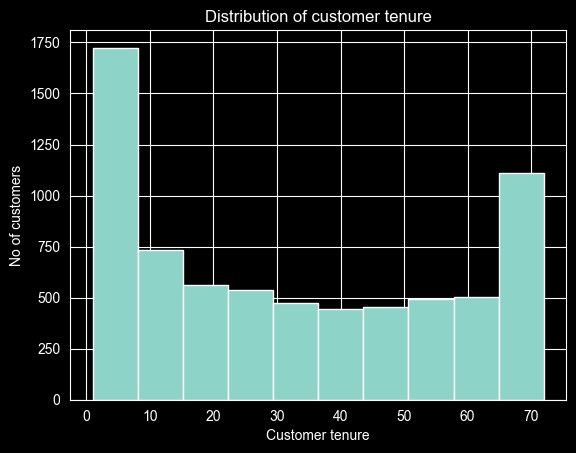

In [11]:
# Task 12 — numerical feature 1: distribution plot
df_clean["tenure"].plot(kind='hist')
plt.title("Distribution of customer tenure")
plt.xlabel("Customer tenure")
plt.ylabel("No of customers")
plt.show()

**Observation:** The graph shows that most customers are either new customers with low tenure or long-term customers with high tenure. there are fewer customers in the middle tenure ranges.

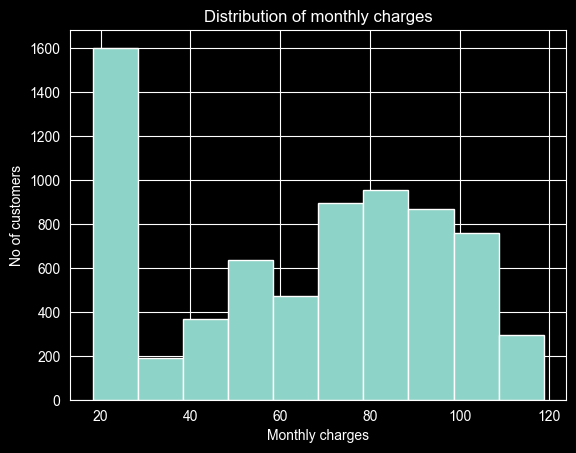

In [12]:
# Task 12 — numerical feature 2: distribution plot
df_clean["MonthlyCharges"].plot(kind='hist')
plt.title("Distribution of monthly charges")
plt.xlabel("Monthly charges")
plt.ylabel("No of customers")
plt.show()

**Observation:** This graph shows that many customers have low monthly charges around $20 to $30 dollars. A large number of customers also have monthly charges between $70 to $100 but there number is comparatively less than those with low monthly charges of $20 to $30

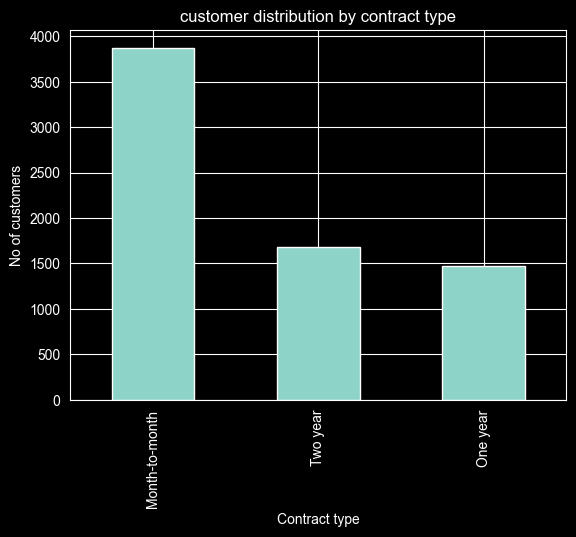

In [13]:
# Task 12 — categorical feature 1: distribution plot
df_clean["Contract"].value_counts().plot(kind='bar')
plt.title("customer distribution by contract type")
plt.xlabel("Contract type")
plt.ylabel("No of customers")
plt.show()



**Observation:** The graph shows that most customers have a month-to-month contract. customers with one year and two year contract are fewer compared to month-to-month customers.

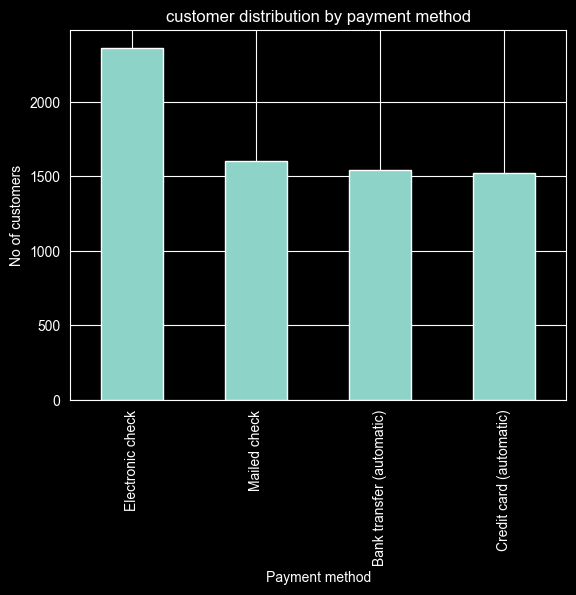

In [14]:
# Task 12 — categorical feature 2: distribution plot
df_clean["PaymentMethod"].value_counts().plot(kind='bar')
plt.title("customer distribution by payment method")
plt.xlabel("Payment method")
plt.ylabel("No of customers")
plt.show()

**Observation:** This graph shows that most customers receive the payment through electronic checks.customers with mailed check, bank transfer, credit card as their payment mode are fewer as compared to electronic checks.

**Answer 13 (outliers / skew and possible explanation):**
The numerical features are not evenly distributed. Tenure has many customers with low and high tenure, while MonthlyCharges has many customers with low charges and some with higher charges. This may be because customers use different services and have different contracts.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [15]:
# Task 14 — churn counts and percentages
print("count :" ,df['Churn'].value_counts())
print("percentage : ",df['Churn'].value_counts(normalize=True)*100)

count : Churn
No     5174
Yes    1869
Name: count, dtype: int64
percentage :  Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
imbalanced because there is a big different between churned and non churned customers.

**Answer 15 (why imbalance might matter later):**
Class imbalance can make the model focus more on the larger class. This may make it harder for the model to correctly identify customers who churn.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


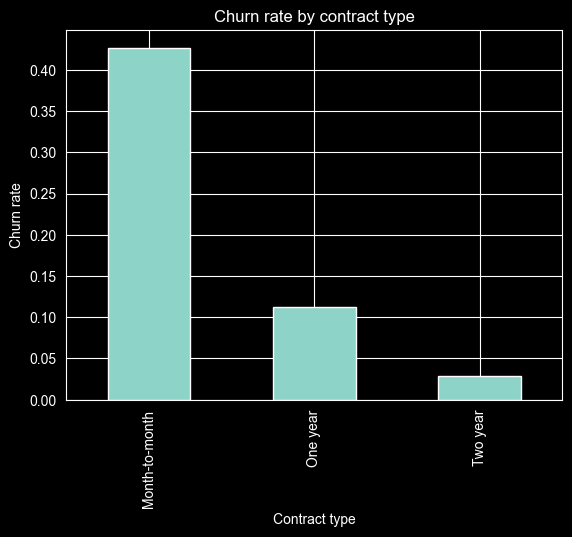

In [16]:
# Task 16 — categorical feature 1 vs Churn
contract_churn=pd.crosstab(df['Contract'],df['Churn'],normalize='index')
print(contract_churn)
contract_churn["Yes"].plot(kind='bar')
plt.title("Churn rate by contract type")
plt.xlabel("Contract type")
plt.ylabel("Churn rate")
plt.show()

**Observation:** month-to-month customers have higher churn rate as compared to one year and two year customers.
**Evidence:** The churn rate is 42.7% for month-to-month customers, 11.27% for one year and 2.83% for two year customers.
**Possible Explanation:** month-to-month customers are easy to leave the company because they have a short term contract.

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


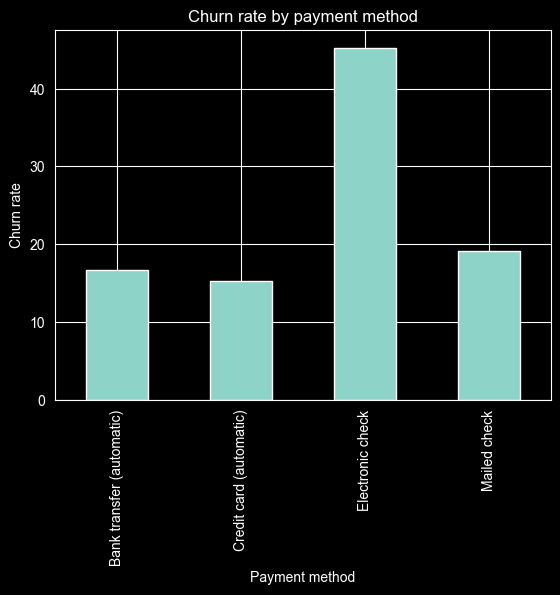

In [17]:
# Task 16 — categorical feature 2 vs Churn
payment_churn=pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100
print(payment_churn)
payment_churn["Yes"].plot(kind='bar')
plt.title("Churn rate by payment method")
plt.xlabel("Payment method")
plt.ylabel("Churn rate")
plt.show()

**Observation:** customers with electronic check as payment mode have higher churn rates than the customers with bank transfer, credit card, mailed check as their payment mode.

**Evidence:** The churn rate is 45.28% for electronic check, 16.7% for bank transfer, 15.2% for credit card and 19.1% for mailed check.

**Possible:** Explanation:Customers using electronic checks may be more likely to leave the company because this payment method may be used by customers who are less committed to the company.


Churn           No        Yes
tenure                       
0       100.000000   0.000000
1        38.009788  61.990212
2        48.319328  51.680672
3        53.000000  47.000000
4        52.840909  47.159091
...            ...        ...
68       91.000000   9.000000
69       91.578947   8.421053
70       90.756303   9.243697
71       96.470588   3.529412
72       98.342541   1.657459

[73 rows x 2 columns]


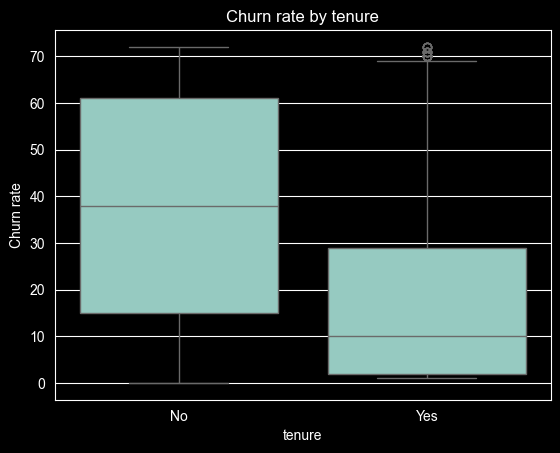

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [19]:
# Task 17 — numerical feature 1 vs Churn
tenure_churn=pd.crosstab(df['tenure'],df['Churn'],normalize='index')*100
print(tenure_churn)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Churn rate by tenure")
plt.xlabel("tenure")
plt.ylabel("Churn rate")
plt.show()
print(df.groupby('Churn')['tenure'].median())

**Observation:**churned customers have lower tenure than non churned customers.

**Evidence:** the median of churned customers is 10 whereas for non churned customers it is 38.

**Possible Explanation:** customers with lower tenure may be more likely to leave the company because they have a short term relationship with the company.

Churn              No    Yes
MonthlyCharges              
18.25           100.0    0.0
18.40           100.0    0.0
18.55           100.0    0.0
18.70           100.0    0.0
18.75           100.0    0.0
...               ...    ...
118.20          100.0    0.0
118.35            0.0  100.0
118.60          100.0    0.0
118.65          100.0    0.0
118.75          100.0    0.0

[1585 rows x 2 columns]


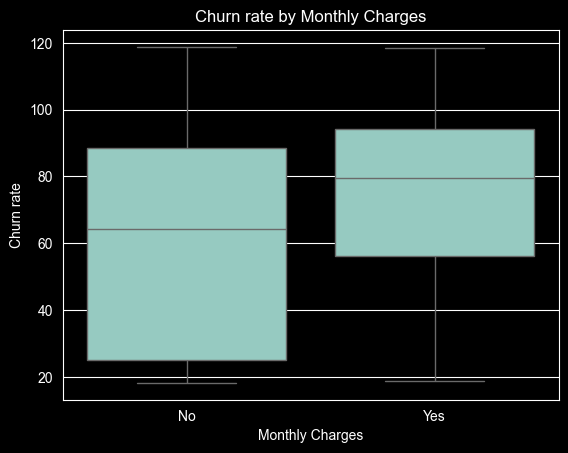

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [20]:
# Task 17 — numerical feature 2 vs Churn
MonthlyCharges=pd.crosstab(df['MonthlyCharges'],df['Churn'],normalize='index')*100
print(MonthlyCharges)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn rate")
plt.show()
print(df.groupby('Churn')['MonthlyCharges'].median())






**Observation:** churned customers have higher monthly charges than non churned customers.

**Evidence:** _..._ the median of monthly charges for churned customers is 79.650 whereas for non churned customer it is 64.425

**Possible Explanation:** the customers with higher monthly charges may be more likely to leave because they may feel because the service is expensive.


---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


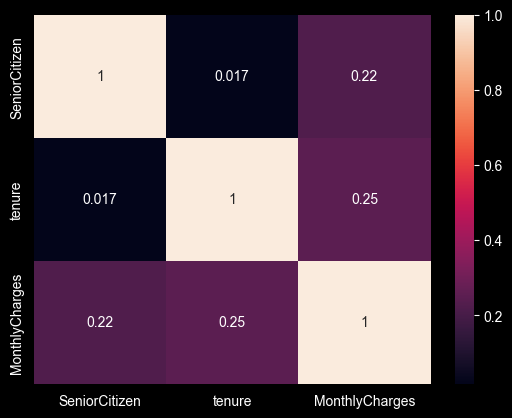

In [21]:
# Task 18 — correlation matrix and heatmap
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)
sns.heatmap(corr_matrix,annot=True)
plt.show()

**Answer 18 (most correlated pairs):**
The most correlated pair is tenure and MonthlyCharges, with a correlation of 0.2479. The second most correlated pair is SeniorCitizen and MonthlyCharges, with a correlation of 0.2202. Both relationships are positive but weak.

**Answer 19 (correlation vs. causation; potential problems):**
correlation does not mean one feature causes another. A strong correlation only shows that two features are related. highly correlated features provide similar information which may cause redundancy in future ML model.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
The main suspect is customerID because it is only an identifier and does not provide useful information about customer behavior. churn should also be not used as input feature because it is the target variable that we want to predict.

**Answer 21 (what would go wrong):**
If a data leakage column is used, the model may show very high accuracy during training and testing. However, it may perform poorly on real-world data because that information would not be available when making the actual prediction.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column           | Type        | Role    | Action | Reason                                                                                      |
|------------------|-------------|---------|--------|---------------------------------------------------------------------------------------------|
| customerID       | Identifier  | —       | Remove | it just identify a customer does not provide useful information about customer behavior.    |
| tenure           | Numerical   | Feature | keep   | it tells for how long the customer is with a company.                                       |
| Contract         | Categorical | Feature | keep   | contract type is stronly related to churn.                                                  |
| Churn            | Categorical | Target  | Keep   | this is what we want to predict in the future.                                              |
| gender           | Categorical | Feature | keep   | it is a customer's demographic information that might help in prediction.
| SeniorCitizen    | Numerical   | Feature | keep   | it tells whether a customer is senior citizen or not.
| Partner          | Categorical | Feature | remove | it does not provide strong or direct information about whether a customer will churn.
| dependents       | Categorical | Feature | keep   | it shows whether the customer has dependents.
| PhoneService     | Categorical | Feature | keep   | it shows whether a customer has phone service.
| MultipleLines    | Categorical | Feature | keep   | it shows the customer's multiple-line service status.
| InternetService  | Categorical | Feature | keep   | it shows the type of internet service.
| OnlineSecurity   | Categorical | Feature | keep   | it shows whether a customer has online security service.
| OnlineBackup     | Categorical | Feature | keep   | it shows whether a customer has online backup service.
| DeviceProtection | Categorical | Feature | keep   | it shows whether the customer's device is protected.
| TechSupport      | Categorical | Feature | keep   | it shows whether a customer has technical support.
| StreamingTV      | Categorical | Feature | keep   | it shows whether a customer has streaming TV service.
| StreamingMovies  | Categorical | Feature | keep   | it shows whether a customer has streaming Movie service.
| PaperlessBilling | Categorical | Feature | keep   | it shows the customer's billing method.
| PaymentMethod    | Categorical | Feature | keep   | it shows the customer's payment method and payment method may be related to churn.
| MonthlyCharges   | Categorical | Feature | keep   | it shows the customer's monthly charges.
| TotalCharges     | Categorical | Feature | keep   | it shows the customer's total charges.
_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [22]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df_clean.copy()
clean_df=clean_df.drop(columns=["customerID","Partner"])
clean_df = clean_df.drop_duplicates()
clean_df=clean_df.dropna()
print(clean_df.columns)
# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='str')


In [23]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print(clean_df.info())
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 7009 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7009 non-null   str    
 1   SeniorCitizen     7009 non-null   int64  
 2   Dependents        7009 non-null   str    
 3   tenure            7009 non-null   int64  
 4   PhoneService      7009 non-null   str    
 5   MultipleLines     7009 non-null   str    
 6   InternetService   7009 non-null   str    
 7   OnlineSecurity    7009 non-null   str    
 8   OnlineBackup      7009 non-null   str    
 9   DeviceProtection  7009 non-null   str    
 10  TechSupport       7009 non-null   str    
 11  StreamingTV       7009 non-null   str    
 12  StreamingMovies   7009 non-null   str    
 13  Contract          7009 non-null   str    
 14  PaperlessBilling  7009 non-null   str    
 15  PaymentMethod     7009 non-null   str    
 16  MonthlyCharges    7009 non-null   float64
 17  TotalCharge

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Most customers did not churn, while fewer customers churned.
- Evidence: 73.46% customers did not churn, while 26.54% customers churned.
- Interpretation: The target variable is imbalanced, so a future ML model should pay attention to the smaller churn class.

**Finding 2**
- Observation: Month-to-month customers have a much higher churn rate than customers with longer contracts.
- Evidence: Month-to-month churn = 42.7%, one-year = 11.3%, two-year = 2.8%.
- Interpretation: Customers with longer contracts may be more likely to stay with the company.

**Finding 3**
- Observation: Churned customers generally have lower tenure than non-churned customers.
- Evidence: Median tenure of churned customers was about 10 months, while non-churned customers was about 38 months.
- Interpretation: Newer customers may be more likely to leave the company.

**Finding 4**
- Observation: Churned customers generally have higher monthly charges than non-churned customers.
- Evidence: Median monthly charge for churned customers was about 79.65, compared with 64.43 for non-churned customers.
- Interpretation: Customers with higher monthly charges may be more likely to churn, possibly because they feel the service is expensive.

**Finding 5**
- Observation: Customers using electronic checks have a higher churn rate than customers using other payment methods.
- Evidence: Electronic check churn rate was about 45.28%, compared with around 15–19% for the other payment methods.
- Interpretation: Payment method is associated with churn and may be useful for predicting customer churn.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?

   The most important data-quality issue was that TotalCharges was stored as text instead of numeric data. Some values were blank or invalid, so they had to be converted to numeric values and handled as missing values.
2. What was the most interesting pattern you discovered?

   The most interesting pattern was that month-to-month customers had a much higher churn rate than one-year and two-year contract customers.
3. Which feature seems most useful for predicting churn?

   Contract seems to be one of the most useful features for predicting churn because its churn rates are very different across contract types.
4. Which feature should probably not be used, and why?

  customerID should not be used because it is only an identifier and does not provide meaningful information about customer churn.
   partner should also be not used as input feature because it does not provide strong/useful information about customer behavior.

5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?

   Before ML modeling, categorical features will need to be encoded into numerical form. Numerical features may also need scaling depending on the ML algorithm. The target variable will need to be prepared for modeling.
6. What would you do next if you had another 3 hours?

  If I had another 3 hours, I would perform more detailed EDA, investigate the important churn patterns further, prepare the data for ML modeling, and test a few machine learning models.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook